# <center>Linear regression I: finite-sample theory</center>
### <center>Alfred Galichon (NYU)</center>
## <center>'math+econ+code' masterclass series: econometrics</center>
#### <center>With python code examples</center>

© 2018–2026 by Alfred Galichon. Past and present support from NSF grant DMS-1716489, ERC grant CoG-866274 are acknowledged, as well as inputs from contributors listed [here](http://www.math-econ-code.org/team).

**If you reuse material from this masterclass, please cite as:**<br>
Alfred Galichon, 'math+econ+code' masterclass series. https://www.math-econ-code.org/

### Learning objectives

* Derive the OLS estimator as the orthogonal projection of $y$ onto the column span of $X$, and implement it from scratch.

* State and prove the Frisch–Waugh–Lovell (FWL) theorem; verify it numerically by recovering a regression coefficient from a residual-on-residual regression.

* State and prove the Gauss–Markov theorem and verify by Monte Carlo that OLS dominates an alternative linear unbiased estimator (split-sample averaging).

* Derive the exact finite-sample distributions of $\hat\beta$, $\hat\sigma^2$, the $t$-statistic, and the $F$-statistic under the classical Gaussian assumption, and confirm them by simulation.

* Compare a hand-coded OLS routine against the `statsmodels` library on the Mincer earnings regression.

### References

**[H]** Hansen, B. E. (2022). *Econometrics*. Princeton University Press. Chapter 3.

**[MHE]** Angrist, J. D., and Pischke, J.-S. (2009). *Mostly Harmless Econometrics*. Princeton University Press. Chapter 3.

**[FWL]** Frisch, R., and Waugh, F. V. (1933). 'Partial Time Regressions as Compared with Individual Trends'. *Econometrica*, 1(4), 387–401. Lovell, M. C. (1963). 'Seasonal Adjustment of Economic Time Series and Multiple Regression Analysis'. *JASA*, 58(304), 993–1010.

**[M]** Mroz, T. A. (1987). 'The Sensitivity of an Empirical Model of Married Women's Hours of Work to Economic and Statistical Assumptions'. *Econometrica*, 55(4), 765–799.

# Motivation: regression as a basic tool

* The linear regression model is the most widely used tool in empirical economics. Whether the object of interest is a structural parameter, a treatment effect, or a demand elasticity, the empirical analysis often reduces to OLS applied to a carefully chosen specification.

* This lecture develops the *finite-sample* theory of OLS: the algebraic and geometric properties that hold for any $I$, with no asymptotic approximation. The next lecture will revisit the same estimator from the asymptotic angle and relax the normality assumption.

* We work throughout with the Mincer earnings function, the canonical regression of log-wage on education and a quadratic in experience, applied to the Mroz (1987) sample of 428 working women already encountered in Lecture 1.

## Loading our libraries

We will use `numpy` for linear algebra, `scipy.stats` for finite-sample distributions, `matplotlib` for plotting, and `statsmodels` as the benchmark library. The latter is not pre-installed on Colab and may need an `!pip install statsmodels`.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from types import SimpleNamespace
import statsmodels.api as sm

rng = np.random.default_rng(777)
plt.rcParams['figure.figsize'] = (8, 4.5)


## Loading our data: the Mincer regression on Mroz (1987)

We restrict the Mroz sample to working women, define the log hourly wage $y_i = \log(\text{wage}_i)$, and build the regressor matrix
$$
x_i = \bigl(1,\;\text{educ}_i,\;\text{exper}_i,\;\text{exper}_i^2\bigr)^\top.
$$
The intercept is the first column of $X$ throughout. (As before: if the URL is unreachable, use `pip install wooldridge` and `wooldridge.data('mroz')`.)

In [2]:
url = 'https://vincentarelbundock.github.io/Rdatasets/csv/sampleSelection/Mroz87.csv'
try:
    mroz = pd.read_csv(url)                       # Rdatasets Mroz87 (needs a network)
except Exception:
    # Offline fallback: the identical Mroz (1987) data ships with the `wooldridge` package.
    import wooldridge
    mroz = (wooldridge.data('mroz')
            .rename(columns={'inlf': 'lfp', 'kidslt6': 'kids5', 'kidsge6': 'kids618'})
            .copy())
mroz_w = mroz.loc[mroz['lfp'] == 1].copy()
mroz_w['lwage'] = np.log(mroz_w['wage'])

y_i = mroz_w['lwage'].values
X_i_k = np.column_stack([
    np.ones(len(mroz_w)),
    mroz_w['educ'].values,
    mroz_w['exper'].values,
    mroz_w['exper'].values ** 2,
])
var_names = ['intercept', 'educ', 'exper', 'exper^2']
I, K = X_i_k.shape
print(f'I = {I}, K = {K}')
print(f'Design matrix X_i_k has shape {X_i_k.shape}; outcome y_i has shape {y_i.shape}.')


I = 428, K = 4
Design matrix X_i_k has shape (428, 4); outcome y_i has shape (428,).


# 1. OLS as orthogonal projection

## 1.1 Setup and assumptions

The linear model is
$$
y = X\beta + \varepsilon,
$$
with $y\in\mathbb{R}^I$, $X\in\mathbb{R}^{I\times K}$, $\beta\in\mathbb{R}^K$. We assume:

**(A1)** $X$ has full column rank: $\operatorname{rank}(X)=K$.<br>
**(A2)** Strict exogeneity: $\mathbb{E}[\varepsilon\mid X]=0$.<br>
**(A3)** Spherical errors: $\operatorname{Var}(\varepsilon\mid X)=\sigma^2 \mathbf{I}_I$ for some $\sigma^2>0$.<br>
**(A4)** *(Optional, for exact inference)* Conditional normality: $\varepsilon\mid X\sim\mathcal{N}(0,\sigma^2 \mathbf{I}_I)$.

Assumptions (A1)–(A2) suffice for OLS to be well-defined and unbiased; (A3) is needed for Gauss–Markov, and (A4) for exact $t$- and $F$-tests.

## 1.2 The least-squares problem

The OLS estimator is the minimizer
$$
\hat\beta := \arg\min_{b\in\mathbb{R}^K} \lVert y - Xb\rVert^2 = \arg\min_{b}\,(y-Xb)^\top(y-Xb).
$$

The first-order condition is the system of *normal equations*
$$
X^\top X\,\hat\beta = X^\top y,
$$
which under (A1) admits the unique solution
$$
\hat\beta = (X^\top X)^{-1} X^\top y.
$$

## 1.3 The geometry of OLS

Define the *projection matrix* (also called the *hat matrix*) and the *annihilator matrix*
$$
P_X := X(X^\top X)^{-1}X^\top, \qquad M_X := \mathbf{I}_I - P_X.
$$
Both are symmetric and idempotent, with $\operatorname{rank}(P_X)=K$ and $\operatorname{rank}(M_X)=I-K$. They satisfy $P_X X = X$, $M_X X = 0$, and $P_X M_X = 0$.

The fitted values and residuals are then
$$
\hat y = X\hat\beta = P_X y, \qquad \hat\varepsilon = y - \hat y = M_X y.
$$
Geometrically, $\hat y$ is the orthogonal projection of $y$ onto the column span of $X$, and $\hat\varepsilon$ is the projection of $y$ onto its orthogonal complement.

## 1.4 A DIY OLS routine

We package the algebra in a single function returning a `SimpleNamespace`. We use `np.linalg.solve` rather than computing $(X^\top X)^{-1}$ explicitly, since solving a linear system is more numerically stable than inverting a matrix and then multiplying.


In [3]:
def ols(X_i_k, y_i):
    I, K = X_i_k.shape
    XtX_k_k = X_i_k.T @ X_i_k
    Xty_k   = X_i_k.T @ y_i
    β_k    = np.linalg.solve(XtX_k_k, Xty_k)
    yhat_i = X_i_k @ β_k
    εhat_i = y_i - yhat_i
    s2     = (εhat_i @ εhat_i) / (I - K)       # unbiased variance estimator
    V_k_k  = s2 * np.linalg.inv(XtX_k_k)       # Var(β̂) under (A1)–(A3)
    se_k   = np.sqrt(np.diag(V_k_k))
    return SimpleNamespace(
        β_k=β_k, yhat_i=yhat_i, εhat_i=εhat_i,
        s2=s2, V_k_k=V_k_k, se_k=se_k,
        I=I, K=K,
    )

fit = ols(X_i_k, y_i)
print(f"{'name':<12s}{'β̂':>12s}{'s.e.':>12s}{'t-stat':>10s}")
for name, b, s in zip(var_names, fit.β_k, fit.se_k):
    print(f'{name:<12s}{b:>12.5f}{s:>12.5f}{b/s:>10.3f}')
print(f'\nσ̂² = {fit.s2:.6f},   σ̂ = {np.sqrt(fit.s2):.6f}')


name                  β̂        s.e.    t-stat
intercept       -0.52204     0.19863    -2.628
educ             0.10749     0.01415     7.598
exper            0.04157     0.01318     3.155
exper^2         -0.00081     0.00039    -2.063

σ̂² = 0.444116,   σ̂ = 0.666420


## 1.5 Sanity checks

The two algebraic properties most worth checking are:

* the residuals are orthogonal to every regressor: $X^\top\hat\varepsilon = 0$;
* if $X$ contains an intercept (a column of ones), the residuals sum to zero.

These follow from the normal equations and serve as a useful debugging tool.

In [4]:
print(f'max |X^T εhat|       = {np.max(np.abs(X_i_k.T @ fit.εhat_i)):.3e}')
print(f'sum of residuals     = {fit.εhat_i.sum():.3e}')
print(f'mean(yhat) - mean(y) = {fit.yhat_i.mean() - y_i.mean():.3e}')


max |X^T εhat|       = 1.746e-11
sum of residuals     = -2.025e-13
mean(yhat) - mean(y) = 6.661e-16


## 1.6 Comparison with `statsmodels`

In [5]:
sm_fit = sm.OLS(y_i, X_i_k).fit()
print('Coefficients comparison (DIY vs. statsmodels):')
print(f"{'name':<12s}{'β̂ (DIY)':>14s}{'β̂ (sm)':>14s}{'difference':>15s}")
for name, b_diy, b_sm in zip(var_names, fit.β_k, sm_fit.params):
    print(f'{name:<12s}{b_diy:>14.6f}{b_sm:>14.6f}{b_diy - b_sm:>15.2e}')


Coefficients comparison (DIY vs. statsmodels):
name              β̂ (DIY)       β̂ (sm)     difference
intercept        -0.522041     -0.522041       2.84e-14
educ              0.107490      0.107490      -1.87e-15
exper             0.041567      0.041567      -1.13e-15
exper^2          -0.000811     -0.000811       4.23e-17


# 2. The Frisch–Waugh–Lovell theorem

## 2.1 Statement

Partition the regressor matrix as $X = [X_1\;\;X_2]$ with $X_1\in\mathbb{R}^{I\times K_1}$ and $X_2\in\mathbb{R}^{I\times K_2}$, and conformably $\beta = (\beta_1^\top,\beta_2^\top)^\top$, so that the regression equation reads $y = X_1\beta_1 + X_2\beta_2 + \varepsilon$. Let $M_1 := \mathbf{I}_I - X_1(X_1^\top X_1)^{-1}X_1^\top$ be the annihilator of $X_1$.

---

**Theorem (Frisch–Waugh–Lovell).** The OLS estimator $\hat\beta_2$ from regressing $y$ on $[X_1\;\;X_2]$ coincides with the OLS estimator from regressing the *residualized* outcome $M_1 y$ on the *residualized* regressors $M_1 X_2$:
$$
\hat\beta_2 = \bigl((M_1 X_2)^\top(M_1 X_2)\bigr)^{-1}(M_1 X_2)^\top(M_1 y).
$$

Moreover, the residuals from these two regressions coincide.

---

**Proof.** Write the normal equations in block form:
$$
\begin{pmatrix} X_1^\top X_1 & X_1^\top X_2 \\ X_2^\top X_1 & X_2^\top X_2 \end{pmatrix}
\begin{pmatrix} \hat\beta_1 \\ \hat\beta_2 \end{pmatrix} =
\begin{pmatrix} X_1^\top y \\ X_2^\top y \end{pmatrix}.
$$
The first block gives $\hat\beta_1 = (X_1^\top X_1)^{-1}X_1^\top(y - X_2\hat\beta_2)$. Substituting into the second block:
$$
X_2^\top X_1 (X_1^\top X_1)^{-1} X_1^\top (y - X_2\hat\beta_2) + X_2^\top X_2\,\hat\beta_2 = X_2^\top y,
$$
which, using $X_1(X_1^\top X_1)^{-1}X_1^\top = I - M_1$ and rearranging, becomes
$$
X_2^\top M_1 X_2\,\hat\beta_2 = X_2^\top M_1 y.
$$
Since $M_1$ is symmetric and idempotent, $X_2^\top M_1 X_2 = (M_1 X_2)^\top(M_1 X_2)$ and $X_2^\top M_1 y = (M_1 X_2)^\top(M_1 y)$, which yields the claim. The residual identity follows directly. $\square$

## 2.2 Numerical verification

Take the Mincer regression as the full model, with $X_1 = [\mathbf{1}\;\text{exper}\;\text{exper}^2]$ as the controls and $X_2 = [\text{educ}]$ as the regressor of interest. We expect the FWL coefficient to match the educ coefficient from §1.4 to numerical precision.

In [6]:
# Partition: X1 = controls (intercept, exper, exper^2); X2 = educ
X1_i_k = X_i_k[:, [0, 2, 3]]
X2_i_1 = X_i_k[:, [1]]

# Annihilator M_1 = I - X_1 (X_1' X_1)^{-1} X_1'
def residualize(W_i_k, Z_i_l):
    # Return M_W Z = Z minus the OLS prediction of Z on W.
    γ_k_l = np.linalg.solve(W_i_k.T @ W_i_k, W_i_k.T @ Z_i_l)
    return Z_i_l - W_i_k @ γ_k_l

ỹ_i    = residualize(X1_i_k, y_i)
X̃2_i_1 = residualize(X1_i_k, X2_i_1)

# OLS of ỹ on X̃2 (no extra intercept needed: it has been residualized out)
β_fwl = np.linalg.solve(X̃2_i_1.T @ X̃2_i_1, X̃2_i_1.T @ ỹ_i).item()

print(f'  β̂_educ  (full regression)              = {fit.β_k[1]:.8f}')
print(f'  β̂_educ  (FWL: residualized regression) = {β_fwl:.8f}')
print(f'  difference                              = {fit.β_k[1] - β_fwl:.2e}')


  β̂_educ  (full regression)              = 0.10748964
  β̂_educ  (FWL: residualized regression) = 0.10748964
  difference                              = -1.85e-15


The two coefficients coincide to machine precision. Economically, the OLS coefficient on `educ` in a multivariate regression is the bivariate slope of *the part of `lwage` not explained by experience* on *the part of `educ` not explained by experience*. This "partialling out" interpretation gives regression coefficients a direct interpretation, and is the algebraic foundation of double/debiased machine learning, to which we return in a later lecture on machine learning.

# 3. The Gauss–Markov theorem

## 3.1 Statement

A *linear* estimator of $\beta$ is one of the form $\tilde\beta = Cy$ for some matrix $C\in\mathbb{R}^{K\times I}$ that may depend on $X$ but not on $y$. It is *unbiased* (under (A2)) iff $CX = \mathbf{I}_K$.

---

**Theorem (Gauss–Markov).** Under (A1)–(A3), among all linear unbiased estimators of $\beta$, the OLS estimator $\hat\beta$ has the smallest variance, in the matrix sense:
$$
\operatorname{Var}(\tilde\beta\mid X) - \operatorname{Var}(\hat\beta\mid X) \;\succeq\; 0
$$
for any linear unbiased $\tilde\beta = Cy$. Equivalently, $\operatorname{Var}(c^\top\tilde\beta)\geq\operatorname{Var}(c^\top\hat\beta)$ for every $c\in\mathbb{R}^K$.

---

**Proof.** Write $C = (X^\top X)^{-1}X^\top + D$, so that $\tilde\beta = \hat\beta + Dy$. Unbiasedness imposes $CX = \mathbf{I}_K$, hence $DX = 0$. Then
$$
\operatorname{Var}(\tilde\beta\mid X) = \sigma^2 CC^\top
= \sigma^2\bigl[(X^\top X)^{-1} + DD^\top + (X^\top X)^{-1}X^\top D^\top + DX(X^\top X)^{-1}\bigr],
$$
and the last two cross-terms vanish since $DX = 0$. Therefore
$$
\operatorname{Var}(\tilde\beta\mid X) = \operatorname{Var}(\hat\beta\mid X) + \sigma^2 DD^\top \;\succeq\; \operatorname{Var}(\hat\beta\mid X). \qquad\square
$$

## 3.2 An alternative linear unbiased estimator: subsample OLS

A simple "competitor" to OLS is the estimator obtained by running OLS on a *strict subsample*, i.e., dropping a random subset of observations. With $\mathcal{S}\subset[I]$ of size $I_{\mathcal{S}}<I$,
$$
\tilde\beta_{\mathcal{S}} := \bigl(X_{\mathcal{S}}^\top X_{\mathcal{S}}\bigr)^{-1} X_{\mathcal{S}}^\top y_{\mathcal{S}}.
$$
This is linear in $y$ (with $C$ a $K\times I$ matrix that picks out the rows of $\mathcal{S}$) and unbiased under (A2). But it discards information: heuristically, $X_{\mathcal{S}}^\top X_{\mathcal{S}}\approx (I_{\mathcal{S}}/I)\cdot X^\top X$ so
$$
\operatorname{Var}(\tilde\beta_{\mathcal{S}})\approx \frac{I}{I_{\mathcal{S}}}\cdot \operatorname{Var}(\hat\beta_{\text{OLS}}).
$$
With $I_{\mathcal{S}}=I/2$, the standard deviations should be $\sqrt{2}\approx 1.41$ times those of OLS.

## 3.3 Monte Carlo verification

We fix the design $X$ and the truth $\beta = \hat\beta_{\text{Mroz}}$ from §1.4, draw $\varepsilon^{(m)}\sim\mathcal{N}(0,\hat\sigma^2 \mathbf{I}_I)$ for $m=1,\dots,M$, compute both estimators, and compare empirical standard deviations.

In [7]:
def subsample_ols(X_i_k, y_i, idx):
    return np.linalg.solve(X_i_k[idx].T @ X_i_k[idx], X_i_k[idx].T @ y_i[idx])

# Random but fixed subsample of size I/2: positions i_j, j in [J]
i_j = rng.permutation(I)[: I // 2]

# Fix the truth at the empirical estimates
βtrue_k = fit.β_k.copy()
σ_true = np.sqrt(fit.s2)
R = 5_000

βols_r_k = np.empty((R, K))
βsub_r_k = np.empty((R, K))
for r in range(R):
    ε_i = σ_true * rng.standard_normal(I)
    ym_i = X_i_k @ βtrue_k + ε_i
    βols_r_k[r] = np.linalg.solve(X_i_k.T @ X_i_k, X_i_k.T @ ym_i)
    βsub_r_k[r] = subsample_ols(X_i_k, ym_i, i_j)

print(f'Empirical std deviations across R = {R} Monte Carlo replications')
print(f'(subsample size = {len(i_j)} / {I}):')
print(f"{'name':<12s}{'std(β̂_OLS)':>14s}{'std(β̃_sub)':>14s}{'ratio':>10s}")
for k, name in enumerate(var_names):
    sd_ols = βols_r_k[:, k].std()
    sd_sub = βsub_r_k[:, k].std()
    print(f'{name:<12s}{sd_ols:>14.5f}{sd_sub:>14.5f}{sd_sub/sd_ols:>10.3f}')


Empirical std deviations across R = 5000 Monte Carlo replications
(subsample size = 214 / 428):
name           std(β̂_OLS)   std(β̃_sub)     ratio
intercept          0.19940       0.27255     1.367
educ               0.01413       0.01954     1.383
exper              0.01339       0.01909     1.425
exper^2            0.00040       0.00056     1.394


In [8]:
# Visualize the sampling distributions for the educ coefficient
k_educ = 1


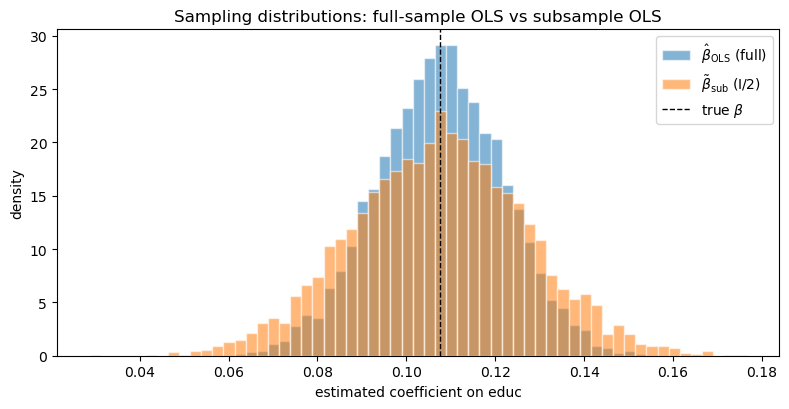

In [9]:
fig, ax = plt.subplots(figsize=(8, 4.2))
bins = np.linspace(min(βols_r_k[:, k_educ].min(), βsub_r_k[:, k_educ].min()),
                   max(βols_r_k[:, k_educ].max(), βsub_r_k[:, k_educ].max()), 60)
ax.hist(βols_r_k[:, k_educ], bins=bins, density=True, alpha=0.55, label=r'$\hat\beta_{\mathrm{OLS}}$ (full)',     edgecolor='white')
ax.hist(βsub_r_k[:, k_educ], bins=bins, density=True, alpha=0.55, label=r'$\tilde\beta_{\mathrm{sub}}$ (I/2)', edgecolor='white')
ax.axvline(βtrue_k[k_educ], color='k', ls='--', lw=1.0, label=r'true $\beta$')
ax.set_xlabel(r'estimated coefficient on educ')
ax.set_ylabel('density')
ax.set_title('Sampling distributions: full-sample OLS vs subsample OLS')
ax.legend()
plt.tight_layout()
plt.show()


Both distributions are centered on the true $\beta_{\text{educ}}$, confirming unbiasedness. The subsample distribution is visibly wider: by roughly a factor of $\sqrt{2}$, as predicted. This illustrates the Gauss–Markov result: discarding data reduces efficiency, while OLS attains the lower bound.

# 4. Exact inference under normality

Let us now add assumption (A4): $\varepsilon\mid X\sim\mathcal{N}(0,\sigma^2 \mathbf{I}_I)$. The exact finite-sample distribution of every standard test statistic can then be derived in closed form.

## 4.1 Distribution of $\hat\beta$

Since $\hat\beta = \beta + (X^\top X)^{-1}X^\top\varepsilon$ is a linear function of a Gaussian vector,
$$
\hat\beta\mid X \;\sim\; \mathcal{N}\bigl(\beta,\;\sigma^2(X^\top X)^{-1}\bigr).
$$

## 4.2 Distribution of $\hat\sigma^2$

The residual vector is $\hat\varepsilon = M_X\varepsilon$. Therefore $\hat\varepsilon\mid X\sim\mathcal{N}(0,\sigma^2 M_X)$ and, since $M_X$ has rank $I-K$ and is idempotent,
$$
\frac{(I-K)\hat\sigma^2}{\sigma^2} = \frac{\hat\varepsilon^\top\hat\varepsilon}{\sigma^2} = \frac{\varepsilon^\top M_X\varepsilon}{\sigma^2}\;\sim\;\chi^2_{I-K}.
$$
Crucially, $\hat\beta$ and $\hat\sigma^2$ are *independent* given $X$. Both are functions of
$\varepsilon$ alone, $\hat\beta - \beta = (X^\top X)^{-1}X^\top\varepsilon$ and
$(I-K)\hat\sigma^2 = \varepsilon^\top M_X\varepsilon$, and they depend on it only through the
two orthogonal pieces $P_X\varepsilon$ and $M_X\varepsilon$: the first lies in
$\operatorname{col}(X)$, the second in its orthogonal complement. For a Gaussian
$\varepsilon$, projections onto orthogonal subspaces are independent, and independence
carries over to any functions of them.

## 4.3 The $t$-statistic

Define
$$
t_k := \frac{\hat\beta_k - \beta_k}{\hat\sigma\sqrt{[(X^\top X)^{-1}]_{kk}}}.
$$
The numerator over $\sigma$ is standard normal; $\hat\sigma/\sigma$ equals the square root of $\chi^2_{I-K}/(I-K)$, independent of the numerator. Therefore
$$
t_k \;\sim\; t_{I-K}\quad\text{exactly.}
$$
The exact two-sided $1-\alpha$ confidence interval is
$$
\hat\beta_k \pm t_{I-K,1-\alpha/2}\cdot\hat\sigma\sqrt{[(X^\top X)^{-1}]_{kk}}.
$$

## 4.4 The $F$-statistic

For a linear hypothesis $H_0: R\beta = r$ with $R\in\mathbb{R}^{Q\times K}$ of rank $Q$, define
$$
F := \frac{(R\hat\beta - r)^\top \bigl[R(X^\top X)^{-1}R^\top\bigr]^{-1}(R\hat\beta - r)/Q}{\hat\sigma^2}.
$$
Under (A1)–(A4) and $H_0$, $F\sim F_{Q,\,I-K}$ exactly.

In [10]:
# Compute exact 95% CIs and t-statistics for the Mincer coefficients
α = 0.05
t_crit = stats.t.ppf(1 - α/2, df=I-K)
cilo_k = fit.β_k - t_crit * fit.se_k
cihi_k = fit.β_k + t_crit * fit.se_k
tstat_k = fit.β_k / fit.se_k
pval_k  = 2 * (1 - stats.t.cdf(np.abs(tstat_k), df=I-K))

print(f"{'name':<12s}{'β̂':>10s}{'s.e.':>10s}{'t':>9s}{'p-value':>12s}{'95% CI':>26s}")
for name, b, s, tt, pv, lo, hi in zip(var_names, fit.β_k, fit.se_k, tstat_k, pval_k, cilo_k, cihi_k):
    print(f'{name:<12s}{b:>10.5f}{s:>10.5f}{tt:>9.3f}{pv:>12.4f}'
          f'{f"  [{lo:>7.4f}, {hi:>7.4f}]":>26s}')


name                β̂      s.e.        t     p-value                    95% CI
intercept     -0.52204   0.19863   -2.628      0.0089        [-0.9125, -0.1316]
educ           0.10749   0.01415    7.598      0.0000        [ 0.0797,  0.1353]
exper          0.04157   0.01318    3.155      0.0017        [ 0.0157,  0.0675]
exper^2       -0.00081   0.00039   -2.063      0.0397        [-0.0016, -0.0000]


In [11]:
# F-test of joint significance: H0 : β_educ = β_exper = β_exper^2 = 0
# (i.e. all slopes zero, intercept free)
Q = 3
R_q_k = np.zeros((Q, K))
R_q_k[0, 1] = 1   # educ
R_q_k[1, 2] = 1   # exper
R_q_k[2, 3] = 1   # exper^2
r_q = np.zeros(Q)

dev_q = R_q_k @ fit.β_k - r_q
mid_q_q = np.linalg.inv(R_q_k @ fit.V_k_k @ R_q_k.T)        # already includes σ̂² via V_k_k
F_stat = (dev_q @ mid_q_q @ dev_q) / Q
p_F = 1 - stats.f.cdf(F_stat, dfn=Q, dfd=I-K)
print(f'F-statistic for joint significance of slopes = {F_stat:.4f}')
print(f'F_{{{Q}, {I-K}}} 95% critical value           = {stats.f.ppf(0.95, Q, I-K):.4f}')
print(f'p-value                                       = {p_F:.4e}')


F-statistic for joint significance of slopes = 26.2862
F_{3, 424} 95% critical value           = 2.6259
p-value                                       = 1.3323e-15


## 4.5 Sanity check against `statsmodels`

In [12]:
print(sm_fit.summary(xname=var_names))


                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.157
Model:                            OLS   Adj. R-squared:                  0.151
Method:                 Least Squares   F-statistic:                     26.29
Date:                Wed, 02 Sep 2026   Prob (F-statistic):           1.30e-15
Time:                        17:13:04   Log-Likelihood:                -431.60
No. Observations:                 428   AIC:                             871.2
Df Residuals:                     424   BIC:                             887.4
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
intercept     -0.5220      0.199     -2.628      0.0

The DIY t-stats, p-values, and 95% confidence intervals match the `statsmodels` output to displayed precision. The `F-statistic` reported in the summary header is exactly the joint test we computed by hand.

# 5. Verifying the exact finite-sample distributions

Let us now run a Monte Carlo experiment to confirm visually that
$$
\frac{(I-K)\hat\sigma^2}{\sigma^2}\sim\chi^2_{I-K}, \qquad t_k\sim t_{I-K}, \qquad F\sim F_{Q,I-K}
$$
under (A1)–(A4). The design matrix $X$ is held fixed at the Mroz design; only the noise vector is resampled.

One detail decides whether this experiment means anything. The three reference distributions
above are the distributions of these statistics **under the null hypothesis each one tests**.
The $\chi^2$ and $t$ panels are indifferent to the value of $\beta$, both
$\hat\beta-\beta = (X^\top X)^{-1}X^\top\varepsilon$ and $\hat\sigma^2$ depend only on the
noise, but the $F$ statistic is not. Simulating from the *fitted* slopes while testing
$H_0:\beta_{\text{educ}}=\beta_{\text{exper}}=\beta_{\text{exper}^2}=0$ would place the DGP
squarely under the alternative, and $F$ would follow a *noncentral* $F_{Q,I-K}(\lambda)$ with
$\lambda = (R\beta)^\top[R(X^\top X)^{-1}R^\top]^{-1}(R\beta)/\sigma^2 \approx 79$: a
distribution centred near 27, nowhere near the central curve. So the simulation below imposes
the null it is testing: the intercept keeps its fitted value and the slopes are set to zero.

In [13]:
# The F panel below plots the CENTRAL F_{Q, I-K}, which is the distribution of the statistic
# *under the null being tested*. So the null has to hold in the DGP: we keep the fitted
# intercept and σ̂, and set the three slopes to zero, giving R β₀ = r_q exactly. Simulating
# from the fitted slopes instead would put us under the alternative, where F is *noncentral*
# — for this design λ ≈ 79, so the statistic would average about 27 against a 95% critical
# value of 2.6, and the histogram would not overlap the reference curve at all.
βnull_k = βtrue_k.copy()
βnull_k[1:] = 0.0                      # H₀: β_educ = β_exper = β_exper² = 0
print(f'DGP for §5 imposes the null: β = {np.round(βnull_k, 4)}')
print(f'   R β₀ - r_q = {np.round(R_q_k @ βnull_k - r_q, 12)}  (zero, so H₀ holds)')

R = 10_000
βmc_r_k = np.empty((R, K))
s2_r = np.empty(R)
F_r  = np.empty(R)

for r in range(R):
    ε_i = σ_true * rng.standard_normal(I)
    ym_i = X_i_k @ βnull_k + ε_i
    f_r = ols(X_i_k, ym_i)
    βmc_r_k[r] = f_r.β_k
    s2_r[r] = f_r.s2
    dev_q = R_q_k @ f_r.β_k - r_q
    F_r[r] = (dev_q @ np.linalg.inv(R_q_k @ f_r.V_k_k @ R_q_k.T) @ dev_q) / Q

# Studentized education coefficient, centred at the value actually used in the DGP
t_r = (βmc_r_k[:, k_educ] - βnull_k[k_educ]) / np.sqrt(
    s2_r * np.linalg.inv(X_i_k.T @ X_i_k)[k_educ, k_educ]
)

# Verification contract for all three panels. Tolerances come from the Monte Carlo standard
# errors at R = 10,000: ~0.0083 for the mean of F(Q, I-K) and ~0.0022 for a 5% rejection
# frequency, so these bands are about 5-6 MCSE — wide enough to survive a change of seed,
# narrow enough that the old noncentral bug (mean 27.4, rejection frequency 1.000) could not
# possibly slip through.
F_mean_th = (I - K) / (I - K - 2)
rej = (F_r > stats.f.ppf(0.95, Q, I - K)).mean()
chi2_mean = ((I - K) * s2_r / σ_true**2).mean()

print(f'\n{"quantity":<34s}{"simulated":>12s}{"theory":>12s}')
print(f'{"mean of F":<34s}{F_r.mean():>12.4f}{F_mean_th:>12.4f}')
print(f'{"P(F > F_95)":<34s}{rej:>12.4f}{0.05:>12.4f}')
print(f'{"mean of (I-K)σ̂²/σ²":<34s}{chi2_mean:>12.2f}{I-K:>12.2f}')
print(f'{"mean of t":<34s}{t_r.mean():>12.4f}{0.0:>12.4f}')

assert abs(F_r.mean() - F_mean_th) < 0.05, 'simulated F is not centred on the central F'
assert abs(rej - 0.05) < 0.01, f'rejection frequency {rej:.4f} is not near the nominal 5%'
assert abs(chi2_mean - (I - K)) < 4.0, 'scaled residual variance is off its chi-square mean'
assert abs(t_r.mean()) < 0.05, 't-statistic is not centred at zero'
print('\nVerification passed: all three statistics match their null distributions.')


DGP for §5 imposes the null: β = [-0.522  0.     0.     0.   ]
   R β₀ - r_q = [0. 0. 0.]  (zero, so H₀ holds)



quantity                             simulated      theory
mean of F                               1.0104      1.0047
P(F > F_95)                             0.0515      0.0500
mean of (I-K)σ̂²/σ²                     424.16      424.00
mean of t                              -0.0050      0.0000

Verification passed: all three statistics match their null distributions.


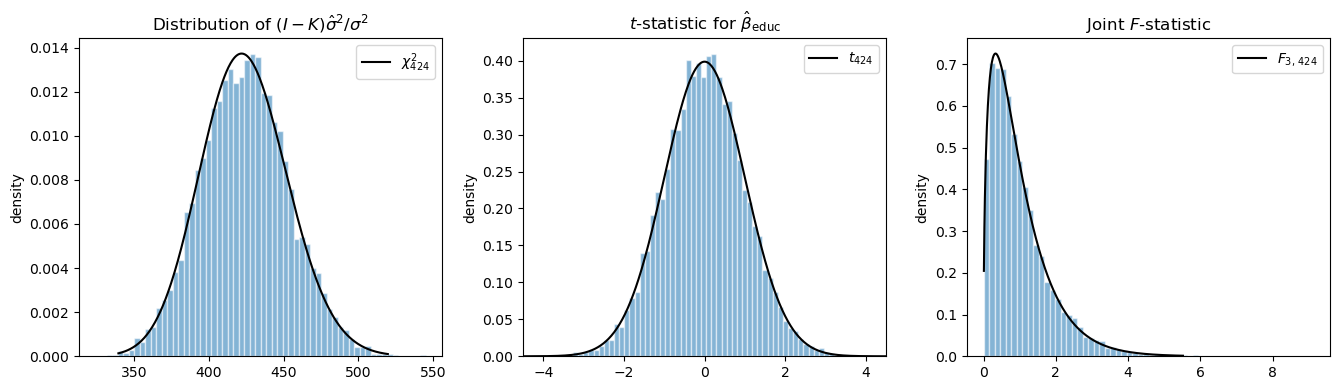

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(13.5, 4.0))

# 1. (I-K) σ̂²/σ² should be chi^2_{I-K}
axes[0].hist((I-K) * s2_r / σ_true**2, bins=60, density=True, alpha=0.55, edgecolor='white')
x_g = np.linspace(stats.chi2.ppf(0.001, I-K), stats.chi2.ppf(0.999, I-K), 400)
axes[0].plot(x_g, stats.chi2.pdf(x_g, I-K), 'k-', lw=1.5, label=fr'$\chi^2_{{{I-K}}}$')
axes[0].set_title(r'Distribution of $(I-K)\hat\sigma^2/\sigma^2$')
axes[0].legend()

# 2. t-stat for educ
axes[1].hist(t_r, bins=60, density=True, alpha=0.55, edgecolor='white')
x_g = np.linspace(-4.5, 4.5, 400)
axes[1].plot(x_g, stats.t.pdf(x_g, I-K), 'k-', lw=1.5, label=fr'$t_{{{I-K}}}$')
axes[1].set_xlim(-4.5, 4.5)
axes[1].set_title(r'$t$-statistic for $\hat\beta_{\mathrm{educ}}$')
axes[1].legend()

# 3. F-stat for joint significance
axes[2].hist(F_r, bins=60, density=True, alpha=0.55, edgecolor='white')
x_g = np.linspace(0.01, stats.f.ppf(0.999, Q, I-K), 400)
axes[2].plot(x_g, stats.f.pdf(x_g, Q, I-K), 'k-', lw=1.5, label=fr'$F_{{{Q},\,{I-K}}}$')
axes[2].set_title(r'Joint $F$-statistic')
axes[2].legend()

for ax in axes:
    ax.set_ylabel('density')
plt.tight_layout()
plt.show()


All three Monte Carlo distributions track their theoretical reference exactly. Note that here, unlike in Lecture 2, the agreement is *not* a CLT statement: it is an *exact* finite-sample identity that holds at every $I$, conditional on $X$. The Gaussian assumption (A4) yields this exactness; in the next lecture we drop it and recover only the asymptotic versions.

# Looking ahead

The finite-sample story above rests on two assumptions whose plausibility deserves scrutiny:

* **(A3) Spherical errors.** Real data are almost never homoskedastic; in particular, the variance of log-wages is widely known to depend on education and experience. The next lecture replaces (A3) with the much weaker condition $\operatorname{Var}(\varepsilon\mid X)=\Omega$ (positive definite, otherwise unconstrained) and develops *heteroskedasticity-robust* standard errors. Gauss–Markov will then no longer hold; OLS will only be efficient relative to a smaller class. **Lecture 5** develops the other response to the same failure: if the error covariance can be modelled rather than merely robustified against, *generalized least squares* restores the Gauss–Markov conclusion, Aitken's theorem, and OLS is BLUE precisely in the spherical case proved here.

* **(A4) Gaussian errors.** This is rarely defensible empirically and is also unnecessary: the CLT, CMT, and Slutsky machinery from Lectures 1–2 will deliver $t_j\xrightarrow{d}\mathcal{N}(0,1)$ asymptotically, with no normality assumption.

The next lecture therefore replays the present analysis from the asymptotic angle, and assembles the toolkit, robust SEs, cluster-robust SEs, that has become standard in applied work; the delta method and the Wald test follow in **Lecture 6**.